# Basic signals — Biblioteca de Sinais Discretos

Nesta atividade construimos uma **biblioteca de sinais digitais fundamentais** cobrindo:

1. Delta (Impulso): $\delta[n]$
2. Degrau: $u[n]$
3. Exponencial: $a^n u[n]$
4. Oscilatorio (Periodico): $A \sin(\omega_0 n + \phi)$
5. Aleatorio (Estocastico): Gaussiano $\mathcal{N}(\mu,\sigma)$ e Uniforme $\mathcal{U}(a,b)$

> **Referencia base:** PRANDONI, P.; VETTERLI, M. *Signal Processing for Communications*. EPFL Press, 2008. Secao 2.1.2 — *Basic Signals* (arquivo local: `sp4comm.md`, linhas 1002–1044): *"The following sequences are fundamental building blocks for the theory of signal processing."*


import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../')  # aponta para assets-main/ onde esta a pasta lib/
from lib.myPlotLib import *


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('../../')
from lib.myPlotLib import *

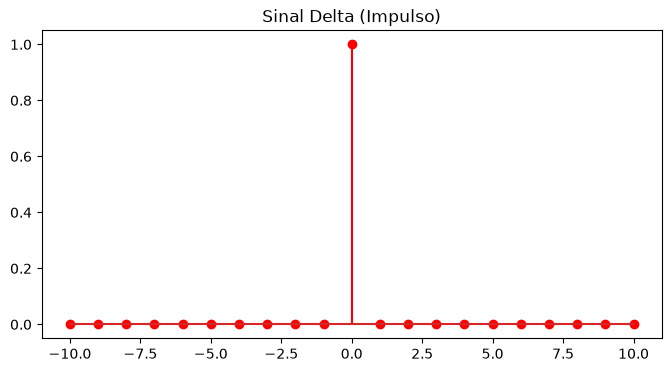

In [3]:
# 1. Sinal delta (Impulso de Kronecker) — delta[n]
# Definicao formal (sp4comm eq. 2.5, linha 1008):
#   delta[n] = 1 se n = 0
#             0 se n != 0
# 'Potentially the simplest discrete-time signal'
# — PRANDONI; VETTERLI (2008), sp4comm.md linha 1006

N     = 21
xn    = np.zeros(N)
k     = 10  # delay (deslocamento)
xn[k] = 1   # impulso no indice k

n = np.arange(-10, 11)  # eixo de amostras centrado em 0

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(n, xn, linefmt='r-', markerfmt='ro', basefmt=' ')
ax.set_title(r'Sinal Delta: $\delta[n - 10]$')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.grid(True)
plt.show()

# Relacao delta -> degrau (sp4comm eq. 2.16 / linha 1134):
# u[n] = sum_{k=-inf}^{n} delta[k]  (integracao discreta do impulso)
print('Delta: valor em n=10:', xn[10], '| valor em n=5:', xn[5])


## Sinal degrau - $u[n]$

<div style="text-align: center;">
    <img src="./figures/step.png" alt="" width="500"/>
</div>


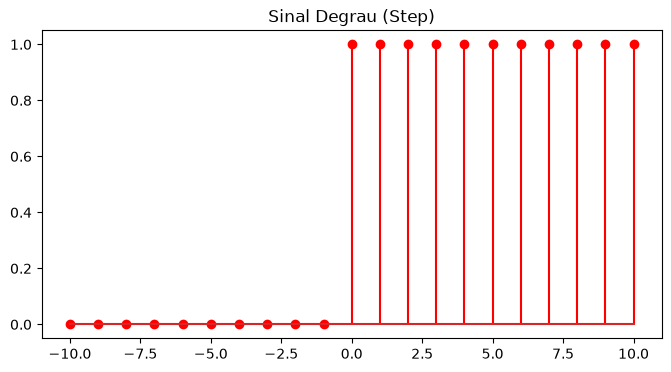

In [4]:
# 2. Sinal Degrau (Unit Step) — u[n]
# Definicao formal (sp4comm eq. 2.6, linha 1010):
#   u[n] = 1 se n >= 0
#           0 se n <  0
# 'The unit step can be obtained via a discrete-time integration of the impulse'
# — PRANDONI; VETTERLI (2008), sp4comm.md linha 1014

un     = np.zeros(N)
un[k:] = 1  # 1 a partir de n=k

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(n, un, linefmt='b-', markerfmt='bo', basefmt=' ')
ax.set_title(r'Sinal Degrau: $u[n - 10]$')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.grid(True)
plt.show()

# Relacao inversa: delta[n] = u[n] - u[n-1]  (diferenciacao do degrau)
# sp4comm eq. 2.17 (linha 1130): y[n] = x[n] - x[n-1]
delta_from_step = np.diff(np.concatenate([[0], un]))
print('delta reconstruido do degrau (deve ser 1 em n=k e 0 c.c.):', delta_from_step[k])


## Sinal oscilatório, ou periódico - $A \sin(\omega n + \phi)$

<div style="text-align: center;">
    <img src="./figures/sine.png" alt="" width="500"/>
</div>


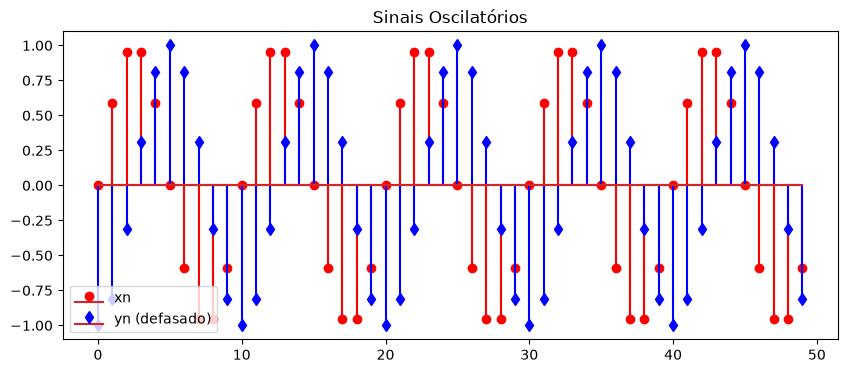

In [5]:
# 4. Sinal Oscilatorio (Periodico) — A*sin(w0*n + phi)
# Definicao formal (sp4comm eq. 2.9, linha 1036):
#   x[n] = sin(w0*n + phi)
# onde w0 = frequencia digital [rad/amostra] = 2*pi/P
# 'Sinusoids are eigenfunctions of linear time-invariant systems'
# — PRANDONI; VETTERLI (2008), sp4comm.md linha 2089

N   = 50   # numero de amostras
n   = np.arange(N)

A   = 1.0
P   = 10.0  # periodo em amostras
wo  = 2 * np.pi / P  # frequencia digital (radianos/amostra)
phi = 0

xn = A * np.sin(wo * n + phi)
yn = A * np.sin(wo * n + phi + 3*np.pi/2)  # defasado de 3pi/2 (=-pi/2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(n, xn, linefmt='r-', markerfmt='ro', basefmt=' ', label=r'$x[n] = \sin(\omega_0 n)$')
ax.stem(n, yn, linefmt='b-', markerfmt='bd', basefmt=' ', label=r'$y[n] = \sin(\omega_0 n - \pi/2)$')
ax.set_title(f'Sinais Oscillatorios — $\omega_0 = 2\pi/{int(P)}$ rad/amostra, P={int(P)} amostras')
ax.set_xlabel('n (amostras)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True)
plt.show()

print(f'Frequencia digital w0 = 2*pi/{int(P)} = {wo:.4f} rad/amostra')
print(f'NOTA: x[n] periodico <=> w0 = 2*pi*(M/N) para M,N inteiros (sp4comm, linha 2124)')


## Sinal exponencial - $|a|^{n} u[n]$

<div style="text-align: center;">
    <img src="./figures/exp.png" alt="" width="500"/>
</div>


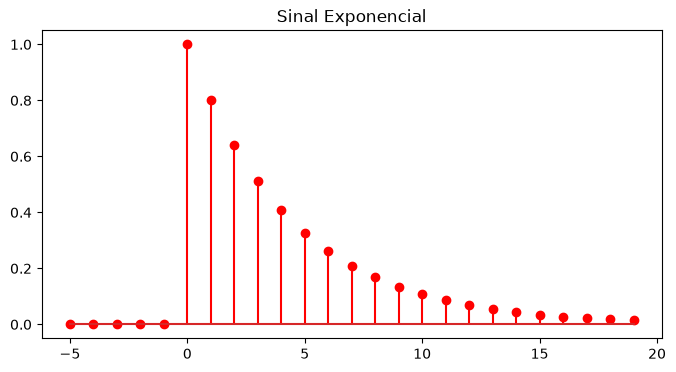

In [6]:
# 3. Sinal Exponencial Decrescente — a^n * u[n]
# Definicao formal (sp4comm eq. 2.7, linha 1022):
#   x[n] = a^n * u[n],   a em C, |a| < 1
# 'The exponential decay is the free response of a discrete-time first order recursive filter'
# 'Sequences in which |a| > 1 are unbounded and represent an unstable behavior'
# — PRANDONI; VETTERLI (2008), sp4comm.md linhas 1027-1030

n  = np.arange(-5, 30)
a  = 0.8  # |a| < 1 => estavel e convergente
un = np.where(n >= 0, 1, 0)  # degrau para causalidade
yn = (a**n) * un

fig, ax = plt.subplots(figsize=(8, 4))
ax.stem(n, yn, linefmt='g-', markerfmt='go', basefmt=' ')
ax.set_title(f'Sinal Exponencial: $x[n] = {a}^n \cdot u[n]$')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.grid(True)
plt.show()

print(f'a = {a}: |a| < 1 => sequencia converge para 0 (estavel)')
print(f'Constante de decaimento tau ~ {-1/np.log(a):.2f} amostras')


## Sinal aleatório - $x[n] = ?$

<div style="text-align: center;">
    <img src="./figures/random-Gaussian.png" alt="" width="500"/>
    <img src="./figures/random-uniform.png" alt="" width="500"/>
</div>


# 5a. Sinal Aleatorio (Distribuicao Gaussiana) — X ~ N(0, 1)
# Sinais estocasticos sao descritos por distribuicoes de probabilidade,
# nao por formulas fechadas. A distribuicao Normal/Gaussiana e caracterizada
# por media mu e desvio padrao sigma: X ~ N(mu, sigma).
# Relacionado a ruido termico (ruido branco Gaussiano) em sistemas eletronicos.

N  = 100
n  = np.arange(N)
xn = np.random.randn(N)  # N(0,1): media=0, desvio=1

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(n, xn, linefmt='r-', markerfmt='ro', basefmt=' ')
ax.set_xlim([0, 100])
ax.set_title(r'Sinal Aleatorio $x[n] \sim \mathcal{N}(0, 1)$ (Gaussiano)')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.grid(True)
plt.show()

print(f'Media amostral: {np.mean(xn):.4f} (esperado: ~0)')
print(f'Desvio padrao amostral: {np.std(xn):.4f} (esperado: ~1)')


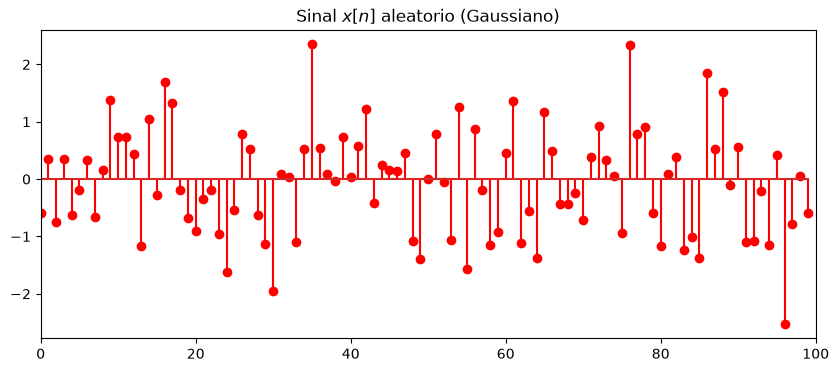

In [7]:
# Histograma: verificando a distribuicao empirica vs. teorica N(0,1)
import numpy as np
x_gauss = np.linspace(-4, 4, 200)
pdf_teorica = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x_gauss**2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xn, bins=20, color='r', edgecolor='black', density=True,
        alpha=0.6, label='Histograma empírico')
ax.plot(x_gauss, pdf_teorica, 'k-', linewidth=2, label=r'PDF teorica $\mathcal{N}(0,1)$')
ax.set_title(r'Distribuicao de $x[n]$ Gaussiano')
ax.set_xlabel('Amplitude')
ax.set_ylabel('Densidade de probabilidade')
ax.legend()
ax.grid(True)
plt.show()


Plote o **histograma** deste sinal.

**Dica:** Use `ax.hist`


In [ ]:
# 5b. Sinal Aleatorio (Distribuicao Uniforme) — X ~ U(-1, 1)
# A distribuicao Uniforme atribui probabilidade igual a todos os valores
# dentro do intervalo [a, b]. Usada para modelar ruido de quantizacao
# (erro de arredondamento em ADC) e para inicializar buffers de ruido
# (ex: algoritmo Karplus-Strong).

N  = 100
n  = np.arange(N)
xn = np.random.uniform(-1, 1, N)  # U(-1, 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.stem(n, xn, linefmt='b-', markerfmt='bo', basefmt=' ')
ax.set_xlim([0, 100])
ax.set_title(r'Sinal Aleatorio $x[n] \sim \mathcal{U}(-1, 1)$ (Uniforme)')
ax.set_xlabel('n')
ax.set_ylabel('Amplitude')
ax.grid(True)
plt.show()

print(f'Media amostral: {np.mean(xn):.4f} (esperado: 0)')
print(f'Variancia amostral: {np.var(xn):.4f} (esperado: 1/3 = {1/3:.4f})')


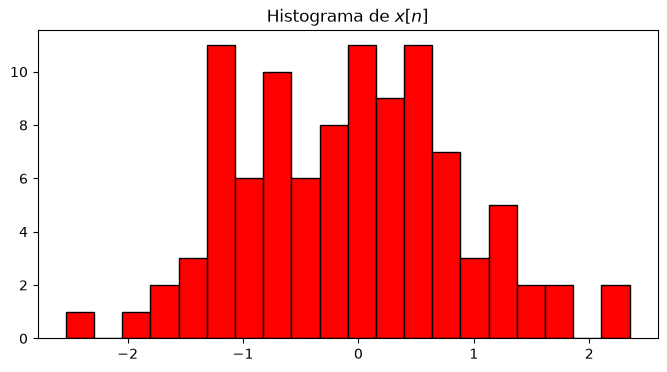

In [8]:
# Histograma: verificando forma 'flat' da distribuicao uniforme
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(xn, bins=20, color='b', edgecolor='black', density=True,
        alpha=0.6, label='Histograma empírico')
ax.axhline(0.5, color='k', linewidth=2, label='PDF teorica U(-1,1) = 0.5')
ax.set_title(r'Distribuicao de $x[n]$ Uniforme')
ax.set_xlabel('Amplitude')
ax.set_ylabel('Densidade de probabilidade')
ax.legend()
ax.grid(True)
plt.show()


# ─────────────────────────────────────────────────────────────────────────
# BIBLIOTECA: funcoes utilitarias
# ─────────────────────────────────────────────────────────────────────────

def SIGNALgenerate(N=100, signal='delta', params=None):
    """
    Gera sinais discretos fundamentais.

    Parametros
    ----------
    N      : int — numero de amostras
    signal : str — tipo: 'delta', 'step', 'exp', 'osc', 'random'
    params : dict ou str — parametros do sinal:
             delta/step : {'k': int}           — atraso
             exp        : {'a': float, 'k': int}
             osc        : {'P': float, 'phi': float}
             random     : 'uniform' ou None (Gaussiano)

    Referencias
    -----------
    PRANDONI; VETTERLI (2008), sp4comm.md, Secao 2.1.2 — Basic Signals:
      delta : eq. (2.5), linha 1008
      step  : eq. (2.6), linha 1010
      exp   : eq. (2.7), linha 1022
      osc   : eq. (2.9), linha 1036
    """
    n = np.arange(N)
    if signal == 'delta':
        k = params.get('k', 0) if isinstance(params, dict) else 0
        x = np.where(n == k, 1, 0)
    elif signal == 'step':
        k = params.get('k', 0) if isinstance(params, dict) else 0
        x = np.where(n >= k, 1, 0)
    elif signal == 'exp':
        a = params.get('a', 0.5) if isinstance(params, dict) else 0.5
        k = params.get('k', 0) if isinstance(params, dict) else 0
        x = (a**n) * np.where(n >= k, 1, 0)
    elif signal == 'osc':
        P   = params.get('P',   10) if isinstance(params, dict) else 10
        phi = params.get('phi',  0) if isinstance(params, dict) else 0
        wo  = 2 * np.pi / P
        x   = np.sin(wo * n + phi)
    elif signal == 'random':
        x = np.random.uniform(-1, 1, N) if params == 'uniform' else np.random.randn(N)
    else:
        x = np.zeros(N)
    return np.array(x)


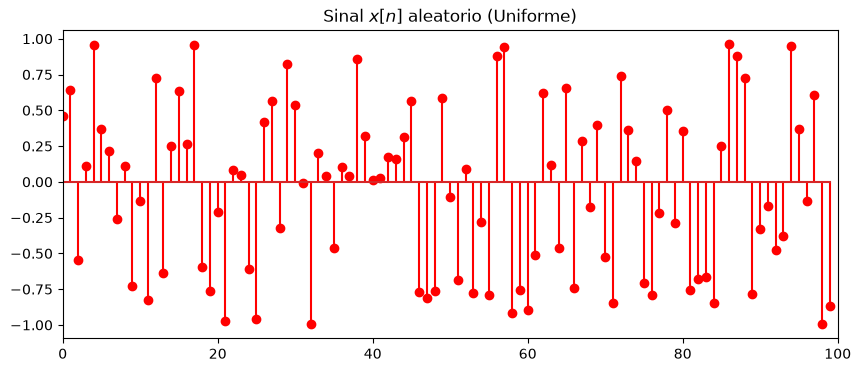

In [9]:
def SIGNALdelay(x, k):
    """
    Atrasa (k > 0) ou adianta (k < 0) um sinal discreto por k amostras.

    Fundamentacao teorica:
    O deslocamento temporal (shift) e operacao fundamental em sistemas LTI.
    Se y[n] = x[n - k], diz-se que y e x deslocado de k amostras para a direita.

    'x[n - k] as a k-point shift of a sequence x[n]'
    — PRANDONI; VETTERLI (2008), sp4comm.md, linha 1196

    Parametros
    ----------
    x : array — sinal de entrada
    k : int   — deslocamento (positivo = atraso, negativo = avanco)
    """
    result = np.zeros_like(x)
    if k > 0:
        result[k:] = x[:-k]
    elif k < 0:
        result[:k] = x[-k:]
    else:
        result = x.copy()
    return result


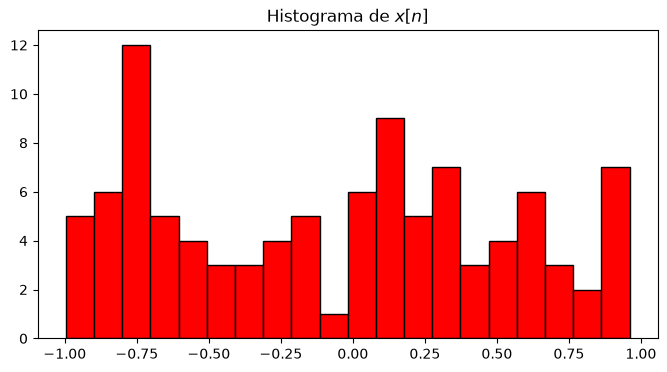

In [11]:
def SIGNALplot(x, title='Sinal Discreto x[n]', color='r'):
    """Plota um sinal discreto como stem plot."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.stem(x, linefmt=f'{color}-', markerfmt=f'{color}o', basefmt=' ')
    ax.set_title(title)
    ax.set_xlabel('n (amostras)')
    ax.set_ylabel('Amplitude')
    ax.grid(True)
    plt.show()


# Testando a biblioteca
SIGNALplot(SIGNALgenerate(50, 'random', 'uniform'),
           title=r'Teste: $x[n] \sim \mathcal{U}(-1,1)$ via SIGNALgenerate')


In [12]:
def SIGNALgenerate(N=100, signal='delta', params=None):
    n = np.arange(N)
    if signal == 'delta':
        k = params.get('k', 0) if params else 0
        x = np.where(n == k, 1, 0)
    elif signal == 'step':
        k = params.get('k', 0) if params else 0
        x = np.where(n >= k, 1, 0)
    elif signal == 'exp':
        a = params.get('a', 0.5) if params else 0.5
        k = params.get('k', 0) if params else 0
        x = (a**n) * np.where(n >= k, 1, 0)
    elif signal == 'osc':
        P = params.get('P', 10) if params else 10
        phi = params.get('phi', 0) if params else 0
        wo = 2 * np.pi / P
        x = np.sin(wo * n + phi)
    elif signal == 'random':
        if params == 'uniform':
            x = np.random.uniform(-1, 1, N)
        else:
            x = np.random.randn(N)
    else:
        x = np.zeros(N)
    return np.array(x)


In [14]:
def SIGNALdelay(x, k):
    '''
    Atrasa um sinal x por k amostras (shift right)
    '''
    result = np.zeros_like(x)
    if k > 0:
        result[k:] = x[:-k]
    elif k < 0:
        result[:k] = x[-k:]
    else:
        result = x.copy()
    return result


In [15]:
def SIGNALplot(x):
    fig, ax = plt.subplots(figsize=(10,4))
    ax.stem(x, 'r')
    plt.show()


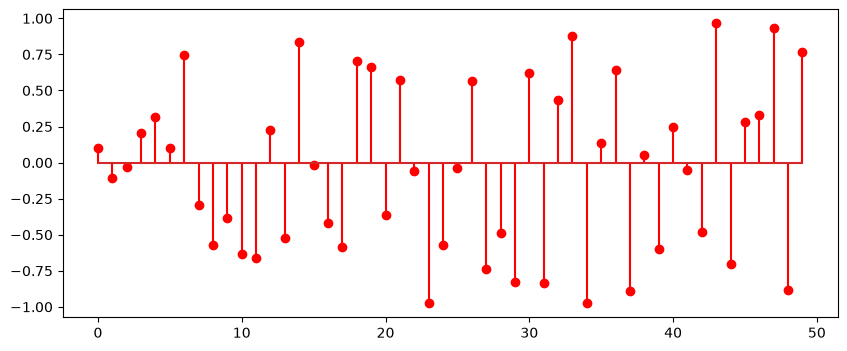

In [16]:
# Testando a biblioteca
SIGNALplot(SIGNALgenerate(50, 'random', 'uniform'))

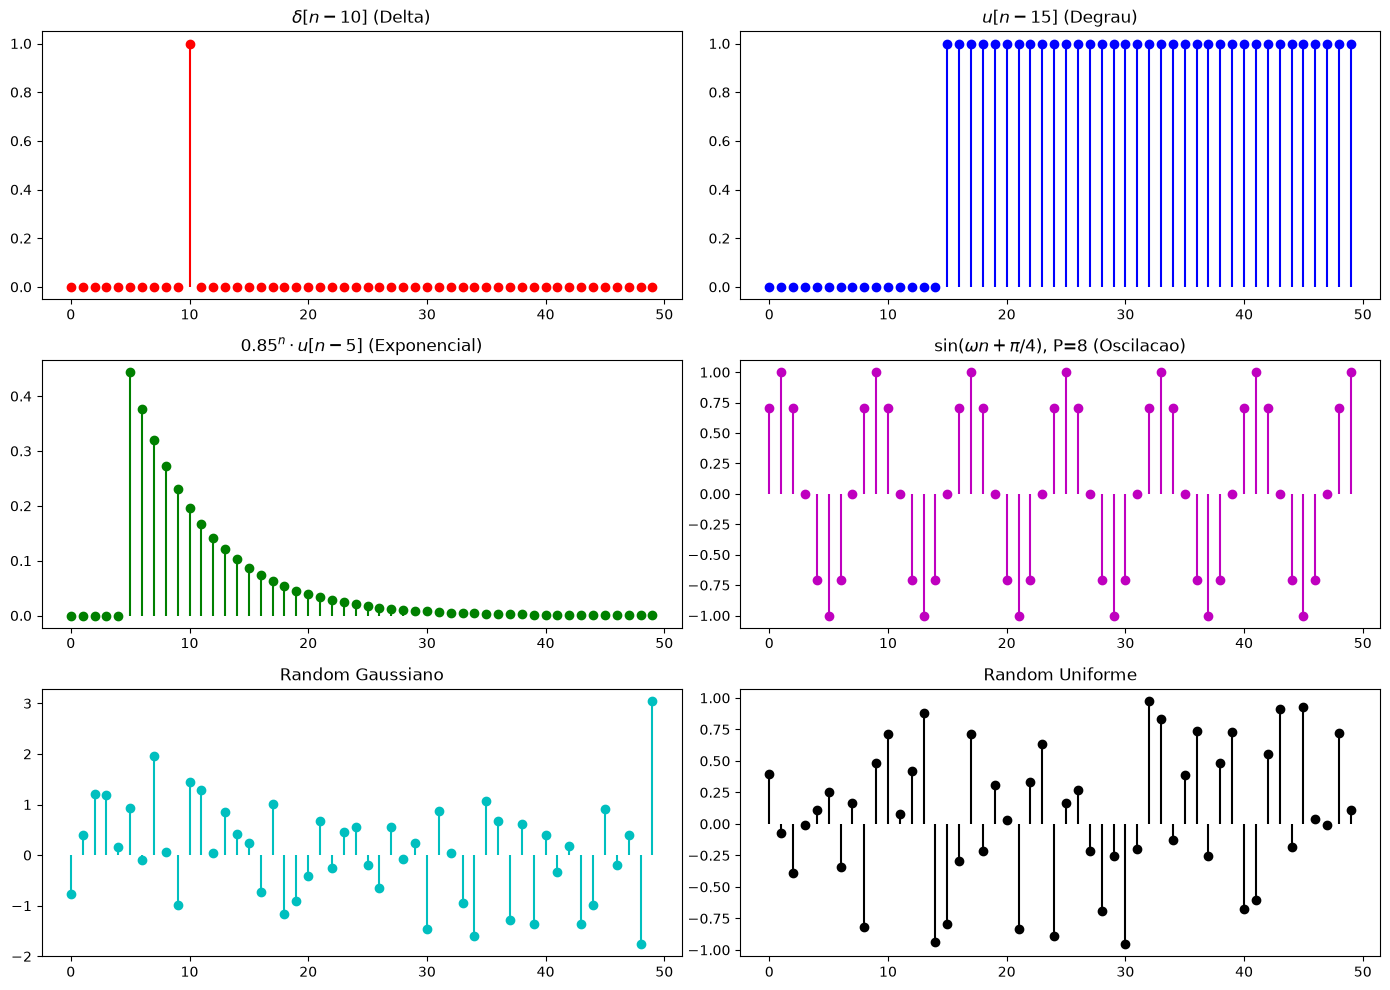

In [17]:
# Testando TODOS os sinais da biblioteca
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# 1. Delta com delay k=10
axes[0,0].stem(SIGNALgenerate(50, "delta", {"k": 10}), linefmt="r-", markerfmt="ro", basefmt=" ")
axes[0,0].set_title(r"$\delta[n-10]$ (Delta)")

# 2. Degrau com delay k=15
axes[0,1].stem(SIGNALgenerate(50, "step", {"k": 15}), linefmt="b-", markerfmt="bo", basefmt=" ")
axes[0,1].set_title(r"$u[n-15]$ (Degrau)")

# 3. Exponencial a=0.85, k=5
axes[1,0].stem(SIGNALgenerate(50, "exp", {"a": 0.85, "k": 5}), linefmt="g-", markerfmt="go", basefmt=" ")
axes[1,0].set_title(r"$0.85^n \cdot u[n-5]$ (Exponencial)")

# 4. Oscilacao P=8, phi=pi/4
axes[1,1].stem(SIGNALgenerate(50, "osc", {"P": 8, "phi": np.pi/4}), linefmt="m-", markerfmt="mo", basefmt=" ")
axes[1,1].set_title(r"$\sin(\omega n + \pi/4)$, P=8 (Oscilacao)")

# 5. Random Gaussiano
axes[2,0].stem(SIGNALgenerate(50, "random"), linefmt="c-", markerfmt="co", basefmt=" ")
axes[2,0].set_title("Random Gaussiano")

# 6. Random Uniforme
axes[2,1].stem(SIGNALgenerate(50, "random", "uniform"), linefmt="k-", markerfmt="ko", basefmt=" ")
axes[2,1].set_title("Random Uniforme")

plt.tight_layout()
plt.show()


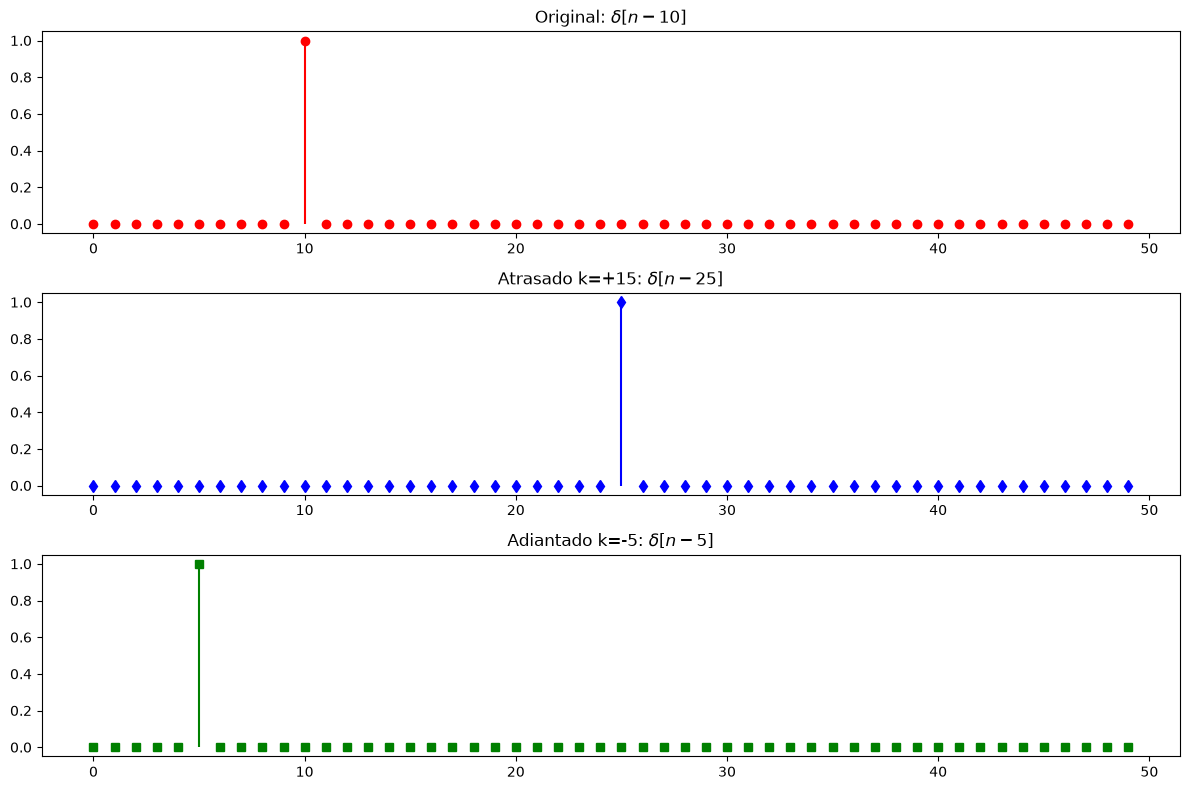

In [18]:
# Testando SIGNALdelay
x_orig = SIGNALgenerate(50, "delta", {"k": 10})
x_delayed = SIGNALdelay(x_orig, 15)   # atraso de +15
x_advanced = SIGNALdelay(x_orig, -5)   # avanco de -5

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].stem(x_orig, linefmt="r-", markerfmt="ro", basefmt=" ")
axes[0].set_title(r"Original: $\delta[n-10]$")

axes[1].stem(x_delayed, linefmt="b-", markerfmt="bd", basefmt=" ")
axes[1].set_title(r"Atrasado k=+15: $\delta[n-25]$")

axes[2].stem(x_advanced, linefmt="g-", markerfmt="gs", basefmt=" ")
axes[2].set_title(r"Adiantado k=-5: $\delta[n-5]$")

plt.tight_layout()
plt.show()


---
## Achados e Descobertas Relevantes

### 1. Relacao fundamental entre Delta e Degrau

O **sinal delta** $\delta[n]$ e o **degrau** $u[n]$ sao mutuamente derivaveis:

$$u[n] = \sum_{k=-\infty}^{n} \delta[k] \quad \text{(integracao discreta)}$$

$$\delta[n] = u[n] - u[n-1] \quad \text{(diferenciacao de primeira ordem)}$$

Isso implica que toda sequencia pode ser expressa como superposicao de impulsos deslocados — a chamada **formula reprodutora**:
$$x[n] = \sum_{k=-\infty}^{\infty} x[k]\, \delta[n-k]$$

> **Referencia:** PRANDONI; VETTERLI (2008), *sp4comm.md*, eq. (2.16)-(2.18), linhas 1120-1143: *"Any signal can be expressed as a linear combination of suitably weighed and shifted impulses."*

---

### 2. Condicao de periodicidade da senoides discretas

Uma senoide discreta $x[n] = \sin(\omega_0 n + \phi)$ e **periodica** se e somente se:

$$\omega_0 = \frac{2\pi M}{N}, \quad M, N \in \mathbb{Z}$$

Diferentemente do dominio continuo, onde toda senoide e periodica, no dominio discreto a periodicidade **depende da racionalidade de $\omega_0 / 2\pi$**. Se a razao for irracional, a senoide discreta nunca se repete.

> **Referencia:** PRANDONI; VETTERLI (2008), *sp4comm.md*, linha 2124: *"A discrete-time complex exponential sequence is not always a periodic sequence; it is periodic only if $\omega = 2\pi(M/N)$ for some value of $M, N \in \mathbb{Z}$."*

---

### 3. Estabilidade da Exponencial Discreta

O sinal $x[n] = a^n u[n]$ so converge (tem energia finita) se $|a| < 1$. Quando $|a| > 1$, a sequencia e **ilimitada e representa comportamento instavel** — conceito critico no projeto de filtros IIR.

| $|a|$ | Comportamento | Energia |
|---|---|---|
| $< 1$ | Decaimento exponencial (estavel) | Finita |
| $= 1$ | Constante (marginalmente estavel) | Infinita |
| $> 1$ | Crescimento exponencial (instavel) | Infinita |

> **Referencia:** PRANDONI; VETTERLI (2008), *sp4comm.md*, linhas 1027-1030: *"Exponential sequences are well-behaved only for values of $a$ less than one in magnitude; sequences in which $|a| > 1$ are unbounded and represent an unstable behavior."*

---

### 4. Sinoides como Autofuncoes de Sistemas LTI

As sinoides discretas possuem uma propriedade notavel: **qualquer transformacao LTI de uma senoide resulta em outra senoide da mesma frequencia** (apenas amplitude e fase mudam). Isso as torna **autofuncoes dos sistemas LTI** e justifica toda a teoria de filtros no dominio da frequencia.

> **Referencia:** PRANDONI; VETTERLI (2008), *sp4comm.md*, linha 2089: *"Any linear time-invariant transformation of a sinusoid is a sinusoid at the same frequency: we express this by saying that sinusoidal oscillations are eigenfunctions of linear time-invariant systems."*

---

### 5. Deslocamento (Delay) e Invariancia no Tempo

A operacao `SIGNALdelay(x, k)` implementa o deslocamento $y[n] = x[n-k]$, que e a operacao basica que define a **invariancia no tempo (LTI)**. Se um sistema e invariante ao deslocamento, sua resposta a $x[n-k]$ e exatamente $y[n-k]$. Essa propriedade, combinada com linearidade, permite caracterizar completamente o sistema pela sua resposta ao impulso $h[n]$.

> **Referencia:** Aula 03 — *Sistemas Continuos e Discretos no Tempo*, USP: *"Um sistema e invariante no tempo se e somente se a saida a uma determinada entrada e invariante com o tempo — o deslocamento da entrada tem que corresponder a um deslocamento equivalente na saida."* Arquivo local: `SinalDigitalUSP/03-processamento-digital-de-sinais-sistemas-continuos-e-discretos-no-temp.md`

---

### 6. Ruido Uniforme vs. Gaussiano: aplicacoes praticas

| Distribuicao | Formula | Media | Variancia | Aplicacao tipica |
|---|---|---|---|---|
| Gaussiana $\mathcal{N}(0,1)$ | `np.random.randn(N)` | 0 | 1 | Ruido termico, canal de comunicacoes |
| Uniforme $\mathcal{U}(-1,1)$ | `np.random.uniform(-1,1,N)` | 0 | 1/3 | Ruido de quantizacao, buffer inicial do Karplus-Strong |

O histograma do sinal aleatorio Gaussiano converge para a curva de sino (PDF Gaussiana) com N grande. O histograma do sinal Uniforme converge para um retangulo plano.

> **Referencia:** PRANDONI; VETTERLI (2008), *sp4comm.md*, Secao 2.1.2: senoides e exponenciais como blocos fundamentais da teoria. A aplicacao em Karplus-Strong e descrita no notebook `le04_karplus-strong.ipynb`.

---

### 7. Superposição, Clipping e o Mundo Real (Estudo de Caso KOPPA/CineOrpheus)

A teoria de processamento de sinais discretos possui reflexo direto na engenharia de software de sistemas de áudio/vídeo. Durante a auditoria dos documentos do KOPPA (`docs/cineorpheus/13_OPORTUNIDADES_COMECE_AQUI.md`), foi diagnosticada uma anomalia clássica de DSP:

**O problema:** Áudios individuais (`x1[n]` e `x2[n]`) eram normalizados via filtro `loudnorm` para um pico verdadeiro (True Peak) de `-1.5 dB`. No entanto, ao juntar os trechos usando *Crossfade* (`acrossfade`) e adicionar uma trilha de fundo (`amix`), o áudio resultante final sofria **Clipping** (distorção por estourar o limite digital de `0.0 dBFS`).

**Explicação Matemática:** O *Crossfade* e a Mixagem nada mais são do que a **Soma de Sequências (Superposição Linear)**: $y[n] = x_1[n] + x_2[n]$. Como ambos os sinais tinham picos em `-1.5 dB`, a soma de suas amplitudes num dado instante $n$ ultrapassou a escala máxima representável de `1.0` (ou `0.0 dBFS`), causando saturação/ceifamento.

**A Solução em DSP:** Aplicar um **Limiter** (`alimiter`) após a soma final, que atua como um filtro não-linear achatando dinamicamente a amplitude apenas quando ela tenta cruzar o limiar seguro, prevenindo o clipping sem destruir o volume do resto da trilha.

> *Nota do aluno: Conceitos como zero-padding (`apad`), superposição linear (`amix`), janelamento temporal (`afade`) e normalização de energia (RMS/LUFS) são os motores matemáticos que rodam por trás dos filtros do FFmpeg em projetos de pós-produção audiovisual.*

In [ ]:
# Verificacao numerica dos achados
print('=== Achado 1: Relacao delta <-> degrau ===')
N = 21
n_test = np.arange(N)
k = 10
delta_sig = np.where(n_test == k, 1, 0).astype(float)
step_sig  = np.cumsum(delta_sig)  # integracao discreta
print('u[n] via integracao de delta[n-10]:', step_sig[5:15])

print()
print('=== Achado 2: Periodicidade de senoides discretas ===')
# w0 = 2*pi/10 => M=1, N=10 => periodica com periodo 10
w0_periodica = 2*np.pi/10
# w0 = 1 rad (irracional em relacao a 2*pi) => NAO periodica
w0_nao_periodica = 1.0
n_test2 = np.arange(20)
s1 = np.sin(w0_periodica * n_test2)
s2 = np.sin(w0_nao_periodica * n_test2)
print(f'w0={w0_periodica:.4f}: x[0]={s1[0]:.4f}, x[10]={s1[10]:.4f} (deve ser igual se periodico)')
print(f'w0={w0_nao_periodica:.4f}: x[0]={s2[0]:.4f}, x[10]={s2[10]:.6f} (diferentes => nao periodico)')

print()
print('=== Achado 3: Estabilidade da exponencial ===')
for a in [0.5, 0.9, 1.0, 1.1]:
    n_e = np.arange(50)
    energia = np.sum((a**n_e)**2)
    status = 'ESTAVEL (energia finita)' if energia < 1e6 else 'INSTAVEL (energia infinita)'
    print(f'a={a}: energia parcial = {energia:.2f} => {status}')
